
Datos cargados desde: duffing_resultados.npz


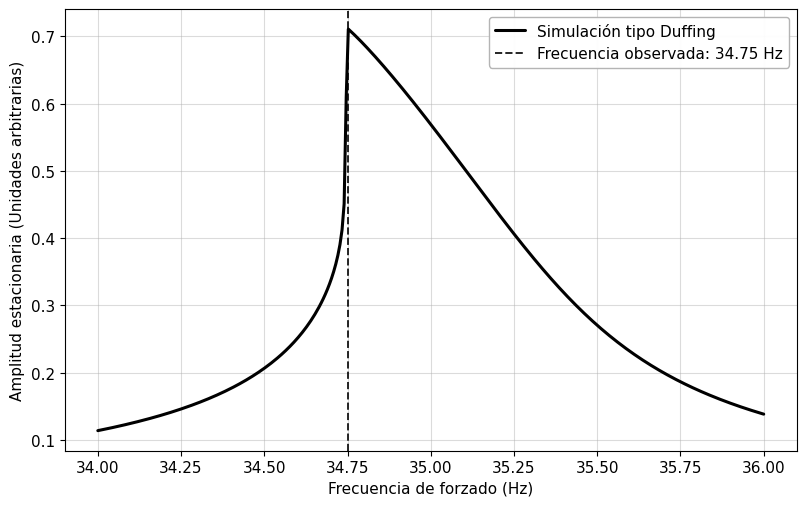


Parámetros usados:
f0 = 35.1289 Hz
omega0 = 220.721 rad/s
alpha = 2.200 1/s
zeta = 0.00498
beta = -1
F_drive = 0.0018
N_freq = 320
N_periodos = 350
puntos_por_periodo = 40
fraccion_descartada = 0.7
rtol = 1e-07
atol = 1e-09


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time


# ============================================================
# CONTROL GENERAL
# ============================================================

# Si True: corre la simulación y guarda datos.
# Si False: carga datos guardados y solo re-grafica.
RE_SIMULAR = False

# Archivo donde se guardan / leen los resultados
ARCHIVO_DATOS = "duffing_resultados.npz"


# ============================================================
# PARÁMETROS DEL MODELO
# ============================================================

# Frecuencia natural lineal aproximada
f0_hz = 35.1289

# Amortiguamiento físico aproximado, en 1/s
alpha_s_inv = 2.2

# Conversión a variables adimensionales
omega0 = 2 * np.pi * f0_hz
zeta = alpha_s_inv / (2 * omega0)

# No linealidad tipo Duffing
# beta > 0: endurecedor
# beta < 0: ablandador
beta = -1.0

# Amplitud del forzado adimensional
F_drive = 1.8e-3


# ============================================================
# PARÁMETROS DEL BARRIDO
# ============================================================

f_min = 34.0
f_max = 36.0

# Más puntos => curva más fluida, pero tarda más
N_freq = 320

# Integración temporal para cada frecuencia
N_periodos = 350
puntos_por_periodo = 40

# Fracción inicial descartada como transitorio
fraccion_descartada = 0.70

# Tolerancias del integrador
rtol = 1e-7
atol = 1e-9

# Escala vertical arbitraria
escala_amplitud = 4.0
offset_amplitud = 0.0

# Línea vertical opcional en la frecuencia experimental observada
mostrar_frec_observada = True
f_observada = 34.75


# ============================================================
# ESTÉTICA DEL GRÁFICO
# ============================================================

COLOR_CURVA = "black"    # rojo oscuro
COLOR_LINEA_REF = "#000000" # negro
COLOR_GRID = "#B0B0B0"      # gris
COLOR_EJES = "#000000"      # negro

FIGSIZE = (8.2, 5.2)
DPI_PNG = 400


# ============================================================
# MODELO DE DUFFING ADIMENSIONAL
# ============================================================

def duffing_adimensional(tau, estado, r, zeta, beta, F_drive):
    """
    Modelo:
        x'' + 2 zeta x' + x + beta x^3 = F_drive cos(r tau)

    Variables:
        estado[0] = x
        estado[1] = x'
    """
    x, v = estado

    dxdtau = v
    dvdtau = (
        F_drive * np.cos(r * tau)
        - 2 * zeta * v
        - x
        - beta * x**3
    )

    return [dxdtau, dvdtau]


def amplitud_por_ajuste(tau, x, r):
    """
    Ajusta:
        x(tau) = a sin(r tau) + b cos(r tau) + c

    Devuelve:
        A = sqrt(a^2 + b^2)
    """
    M = np.column_stack([
        np.sin(r * tau),
        np.cos(r * tau),
        np.ones_like(tau)
    ])

    coef, *_ = np.linalg.lstsq(M, x, rcond=None)
    a, b, c = coef

    A = np.sqrt(a**2 + b**2)
    return A


def simular_una_frecuencia(f_hz, estado_inicial):
    """
    Simula una frecuencia de forzado.

    Hace dos etapas:
    1. Integra el transitorio sin guardar todos los puntos.
    2. Integra la parte estacionaria y ahí calcula la amplitud.
    """
    r = f_hz / f0_hz

    periodo_tau = 2 * np.pi / r

    tau_total = N_periodos * periodo_tau
    tau_transitorio = fraccion_descartada * tau_total
    tau_estacionario = tau_total - tau_transitorio

    # ------------------------------------------------------------
    # 1) Integración del transitorio
    # ------------------------------------------------------------
    sol_trans = solve_ivp(
        fun=duffing_adimensional,
        t_span=(0, tau_transitorio),
        y0=estado_inicial,
        args=(r, zeta, beta, F_drive),
        method="DOP853",
        rtol=rtol,
        atol=atol,
        max_step=periodo_tau / puntos_por_periodo
    )

    if not sol_trans.success:
        raise RuntimeError(f"La integración del transitorio falló en f = {f_hz:.4f} Hz")

    estado_transitorio = sol_trans.y[:, -1]

    # ------------------------------------------------------------
    # 2) Integración de la parte estacionaria
    # ------------------------------------------------------------
    N_puntos_est = int((tau_estacionario / periodo_tau) * puntos_por_periodo)

    tau_eval = np.linspace(
        tau_transitorio,
        tau_total,
        N_puntos_est
    )

    sol_est = solve_ivp(
        fun=duffing_adimensional,
        t_span=(tau_transitorio, tau_total),
        y0=estado_transitorio,
        t_eval=tau_eval,
        args=(r, zeta, beta, F_drive),
        method="DOP853",
        rtol=rtol,
        atol=atol,
        max_step=periodo_tau / puntos_por_periodo
    )

    if not sol_est.success:
        raise RuntimeError(f"La integración estacionaria falló en f = {f_hz:.4f} Hz")

    tau = sol_est.t
    x = sol_est.y[0]

    estado_final = sol_est.y[:, -1]

    A = amplitud_por_ajuste(tau, x, r)

    return A, estado_final


def barrido_frecuencias(frecuencias):
    """
    Hace un barrido ascendente en frecuencia.

    Usa el estado final de una frecuencia como condición inicial
    de la siguiente.
    """
    estado = np.array([0.0, 0.0], dtype=float)
    amplitudes = []

    t_inicio = time.time()

    for i, f in enumerate(frecuencias, start=1):
        A, estado = simular_una_frecuencia(f, estado)
        amplitudes.append(A)

        if i == 1 or i % 10 == 0 or i == len(frecuencias):
            t_actual = time.time() - t_inicio
            print(f"Frecuencia {i:3d}/{len(frecuencias)} | f = {f:.4f} Hz | tiempo = {t_actual:.1f} s")

    t_total = time.time() - t_inicio
    print(f"\nTiempo total de simulación: {t_total:.1f} s")

    return np.array(amplitudes)


# ============================================================
# GUARDADO / CARGA DE DATOS
# ============================================================

def guardar_resultados(nombre_archivo, frecuencias, A, A_plot):
    np.savez(
        nombre_archivo,
        frecuencias=frecuencias,
        A=A,
        A_plot=A_plot,
        f0_hz=f0_hz,
        alpha_s_inv=alpha_s_inv,
        omega0=omega0,
        zeta=zeta,
        beta=beta,
        F_drive=F_drive,
        f_min=f_min,
        f_max=f_max,
        N_freq=N_freq,
        N_periodos=N_periodos,
        puntos_por_periodo=puntos_por_periodo,
        fraccion_descartada=fraccion_descartada,
        rtol=rtol,
        atol=atol,
        escala_amplitud=escala_amplitud,
        offset_amplitud=offset_amplitud,
        f_observada=f_observada
    )
    print(f"\nDatos guardados en: {nombre_archivo}")


def cargar_resultados(nombre_archivo):
    datos = np.load(nombre_archivo, allow_pickle=True)
    print(f"\nDatos cargados desde: {nombre_archivo}")
    return datos


# ============================================================
# SIMULACIÓN O CARGA
# ============================================================

if RE_SIMULAR:
    frecuencias = np.linspace(f_min, f_max, N_freq)
    A = barrido_frecuencias(frecuencias)
    A_plot = escala_amplitud * A + offset_amplitud

    guardar_resultados(ARCHIVO_DATOS, frecuencias, A, A_plot)

else:
    datos = cargar_resultados(ARCHIVO_DATOS)
    frecuencias = datos["frecuencias"]
    A = datos["A"]
    A_plot = datos["A_plot"]


# ============================================================
# GRÁFICO PARA INFORME
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.edgecolor": COLOR_EJES,
    "axes.labelcolor": COLOR_EJES,
    "xtick.color": COLOR_EJES,
    "ytick.color": COLOR_EJES,
    "text.color": COLOR_EJES,
    "axes.titlecolor": COLOR_EJES,
    "legend.edgecolor": COLOR_GRID
})

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    frecuencias,
    A_plot,
    color=COLOR_CURVA,
    linewidth=2.2,
    solid_capstyle="round",
    antialiased=True,
    label="Simulación tipo Duffing"
)

# Si querés marcar algunos puntos pero no todos, descomentá esto:
# ax.plot(
#     frecuencias[::12],
#     A_plot[::12],
#     "o",
#     color=COLOR_CURVA,
#     markersize=3
# )

if mostrar_frec_observada:
    ax.axvline(
        f_observada,
        linestyle="--",
        linewidth=1.4,
        color=COLOR_LINEA_REF,
        alpha=0.85,
        label=f"Frecuencia observada: {f_observada:.2f} Hz"
    )

ax.set_xlabel("Frecuencia de forzado (Hz)")
ax.set_ylabel("Amplitud estacionaria (Unidades arbitrarias)")
# ax.set_title("Simulación cualitativa de una respuesta tipo Duffing")

ax.grid(True, color=COLOR_GRID, alpha=0.45, linewidth=0.8)

leg = ax.legend(frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.95)

fig.tight_layout()

# Guardar en PNG
fig.savefig(
    "simulacion_duffing_respuesta_estacionaria.png",
    dpi=DPI_PNG,
    bbox_inches="tight"
)

# Guardar en PDF (vectorial, mejor para informe)
fig.savefig(
    "simulacion_duffing_respuesta_estacionaria.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARÁMETROS USADOS
# ============================================================

print("\nParámetros usados:")
print(f"f0 = {f0_hz:.4f} Hz")
print(f"omega0 = {omega0:.3f} rad/s")
print(f"alpha = {alpha_s_inv:.3f} 1/s")
print(f"zeta = {zeta:.5f}")
print(f"beta = {beta:.3g}")
print(f"F_drive = {F_drive:.3g}")
print(f"N_freq = {N_freq}")
print(f"N_periodos = {N_periodos}")
print(f"puntos_por_periodo = {puntos_por_periodo}")
print(f"fraccion_descartada = {fraccion_descartada}")
print(f"rtol = {rtol}")
print(f"atol = {atol}")